1. Import the data and group the rows by star. np.loadtxt / np.genfromtxt / astropy.ascii.read — LEC2; check out CODING/ examples


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.optimize

Gaia_Dataset = "gaia_m31_lcs.csv"

dt = [("source_id", "i8"), ("t_year", "f8"), ("gmag", "f8"), ("gmag_err", 'f8')]

df = np.genfromtxt(Gaia_Dataset, delimiter=',', names=True, dtype=dt)

df = df[np.lexsort((df["t_year"], df["source_id"]))]

ids, start, n = np.unique(df["source_id"], return_index=True, return_counts=True)
stars = {sid: df[s:s+k] for sid, s, k in zip(ids, start, n)}

# Sanity checks to make sure the file is correct
print(f"rows: {len(df):,}   (expect 92,590)")
print(f"stars: {len(ids):,}   (expect 2,025)")
print(f"epochs per star: min {n.min()}, median {int(np.median(n))}, max {n.max()}   (expect min >= 30)")
print(f"time range: {df['t_year'].min():.3f} - {df['t_year'].max():.3f}   (expect 2014.6 - 2017.4)")
print(f"G range: {df['gmag'].min():.2f} - {df['gmag'].max():.2f}   (expect < 17)")
print(f"median gmag_err: {1e3*np.median(df['gmag_err']):.2f} mmag")
print(f"NaNs: {sum(np.isnan(df[c]).sum() for c in ('t_year', 'gmag', 'gmag_err'))}")
print(f"non-positive errors: {(df['gmag_err'] <= 0).sum()}")

# Shared setup used by every later task
N = len(ids)
T0 = 2016.0
g_med = np.array([np.median(df["gmag"][a:a+k]) for a, k in zip(start, n)])
plt.style.use("default")


rows: 92,590   (expect 92,590)
stars: 2,025   (expect 2,025)
epochs per star: min 30, median 41, max 99   (expect min >= 30)
time range: 2014.645 - 2017.404   (expect 2014.6 - 2017.4)
G range: 8.26 - 17.30   (expect < 17)
median gmag_err: 2.27 mmag
NaNs: 0
non-positive errors: 0


2. Pick three stars and plot their light curves clearly; think about presentation.
Check residuals for any abnormalities

{'Average Star': 369118427247497728, 'Strongest Trend': 382186599682713984, 'Brightest Star': 381669249398576896}


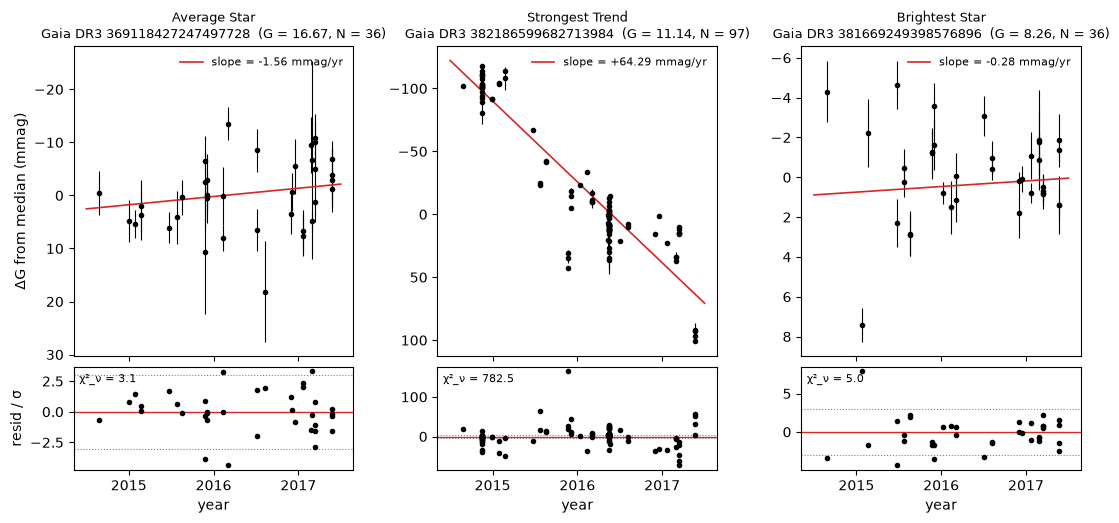

In [27]:
# Task 2: three light curves with fits and residual panels (uses df, ids, start, n, g_med, T0 from cell 1)

def star(i):
    s = df[start[i]:start[i] + n[i]]
    return s["t_year"], s["gmag"], s["gmag_err"]

# --- Quick per-star diagnostics, only used to choose the three stars ---
chi2_const, slope_z = np.empty(len(ids)), np.empty(len(ids))
for i in range(len(ids)):
    t, m, e = star(i)
    w = 1 / e**2
    mbar = np.sum(w * m) / np.sum(w)
    chi2_const[i] = np.sum(w * (m - mbar)**2) / (n[i] - 1)       # reduced chi2 of a flat line
    p, C = np.polyfit(t - T0, m, 1, w=1 / e, cov="unscaled")
    slope_z[i] = p[0] / np.sqrt(C[0, 0])

picks = {
    "Average Star": np.argsort(chi2_const)[len(ids) // 2],        # median flat-line chi2
    "Strongest Trend": np.argmax(np.abs(slope_z)),
    "Brightest Star": np.argmin(g_med),                           # where an error floor bites hardest
}

# --- Figure: 3 columns, light curve on top, normalized residuals below ---
fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05, "wspace": 0.3})
tt = np.linspace(2014.5, 2017.5, 200)

for col, (label, i) in enumerate(picks.items()):
    t, m, e = star(i)
    ref = np.median(m)
    dm = 1e3 * (m - ref)                      # plot in mmag relative to median
    p = np.polyfit(t - T0, m, 1, w=1 / e)
    resid = (m - np.polyval(p, t - T0)) / e   # residuals in units of the quoted error
    chi2r = np.sum(resid**2) / (len(t) - 2)

    top, bot = axes[0, col], axes[1, col]
    top.errorbar(t, dm, yerr=1e3 * e, fmt="o", color="k", ms=3, elinewidth=0.8, capsize=0)
    top.plot(tt, 1e3 * (np.polyval(p, tt - T0) - ref), color="C3", lw=1.2,
             label=f"slope = {1e3*p[0]:+.2f} mmag/yr")
    top.invert_yaxis()                        # brighter = up
    top.set_title(f"{label}\nGaia DR3 {ids[i]}  (G = {ref:.2f}, N = {len(t)})", fontsize=9)
    top.set_ylabel("ΔG from median (mmag)" if col == 0 else "")
    top.legend(fontsize=8, loc="best", frameon=False)

    bot.axhline(0, color="C3", lw=1)
    for k in (-3, 3):
        bot.axhline(k, color="grey", ls=":", lw=0.8)
    bot.plot(t, resid, "o", color="k", ms=3)
    bot.set_ylabel("resid / σ" if col == 0 else "")
    bot.set_xlabel("year")
    bot.text(0.02, 0.85, f"χ²_ν = {chi2r:.1f}", transform=bot.transAxes, fontsize=8)

fig.savefig("task2_lightcurves.pdf", bbox_inches="tight")
print({k: int(ids[i]) for k, i in picks.items()})

3. For one star: unweighted fit of m(t) with np.polyfit.

In [28]:
# Let's pick strongest trend - Gaia DR3 382186599682713984
sid = 382186599682713984
s = df[df["source_id"] == sid]
order = np.argsort(s["t_year"], kind="stable")
# sorts every column together
s = s[order]

t = s["t_year"] - 2016.0
m = s["gmag"]
e = s["gmag_err"]

slope, intercept = np.polyfit(t, m, 1)   # unweighted: no w=
resid = m - np.polyval([slope, intercept], t)
sig_slope = resid.std(ddof=2) / np.sqrt(np.sum((t - t.mean())**2))

print(f"N = {len(t)}  slope = {1e3*slope:+.2f} ± {1e3*sig_slope:.2f} mmag/yr  "
      f"G(2016.0) = {intercept:.4f}  rms resid = {1e3*resid.std(ddof=2):.2f} mmag")

N = 97  slope = +65.37 ± 2.80 mmag/yr  G(2016.0) = 11.1194  rms resid = 21.42 mmag


4. Write your own code solving the weighted normal equations; check you
reproduce polyfit exactly.

In [29]:
def wls(t, m, e):
    A = np.column_stack([t, np.ones_like(t)])
    w = 1.0 / e**2
    ATWA = A.T @ (A * w[:, None])
    C = np.linalg.inv(ATWA)
    beta = np.linalg.solve(ATWA, A.T @ (w * m))
    # beta determined from beta = [slope, intercept]
    return beta, C

In [30]:
beta, C = wls(t, m, e)
p, Cp = np.polyfit(t, m, 1, w=1/e, cov="unscaled")
print(np.max(np.abs(beta - p)), np.max(np.abs(C - Cp)))

1.0200174038743626e-14 3.308722450212111e-24


In [31]:
print("beta:", beta, "\npolyfit:", p)
print("max rel diff, beta:", np.max(np.abs(beta - p) / np.abs(p)))
print("max rel diff, cov: ", np.max(np.abs(C - Cp) / np.abs(Cp)))

beta: [ 0.06428506 11.11564649] 
polyfit: [ 0.06428506 11.11564649]
max rel diff, beta: 1.586709864118533e-13
max rel diff, cov:  2.3747167024180376e-15


5. Now the production run: weighted fit with covariance for every star (a loop over
2,025 regressions). Save slope $s_i$ and its error $σ_i$ from the covariance diagonal.


In [32]:
def fit_all(f=0.0, perms=None):
    s, sig = np.empty(N), np.empty(N)
    for i, (a, k) in enumerate(zip(start, n)):
        r = df[a:a+k]
        m, e = r["gmag"], np.sqrt(r["gmag_err"]**2 + f**2)
        if perms is not None:
            m, e = m[perms[i]], e[perms[i]]   # shuffle (mag, err) pairs vs. time
        beta, C = wls(r["t_year"] - T0, m, e)
        s[i], sig[i] = beta[0], np.sqrt(C[0, 0])
    return s, sig

slopes, sig = fit_all()
z = slopes / sig

np.savez("task5_slopes.npz", source_id=ids, slope=slopes, sig=sig, z=z, g_med=g_med, n=n)

6. Histogram of zi = si/σi. If no star truly varied and the errors were correct, what
distribution must this be? Overplot it

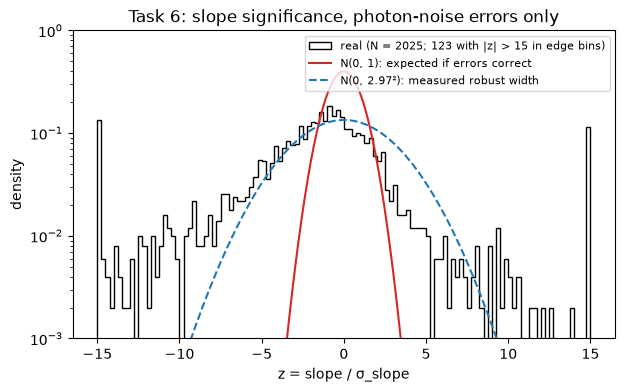

robust width = 2.97
|z| > 3: 760  (expect 5.5 if errors correct)
  z > +3 (dimming): 182   z < -3 (brightening): 578
|z| > 15 (in edge bins): 123
median z = -1.18


In [37]:
def rwidth(x):
    return 1.4826 * np.median(np.abs(x - np.median(x)))

bins = np.linspace(-15, 15, 121)
bw = bins[1] - bins[0]
x = np.linspace(-15, 15, 500)

w = rwidth(z)
n_over = np.sum(np.abs(z) > 15)
zc = np.clip(z, bins[0] + 1e-9, bins[-1] - 1e-9)   # overflow goes into edge bins
wts = np.full(N, 1.0 / (N * bw))

plt.figure(figsize=(7, 4))
plt.hist(zc, bins, weights=wts, histtype="step", color="k",
         label=f"real (N = {N}; {n_over} with |z| > 15 in edge bins)")
plt.plot(x, scipy.stats.norm.pdf(x), "C3", label="N(0, 1): expected if errors correct")
plt.plot(x, scipy.stats.norm.pdf(x, 0, w), "C0--", label=f"N(0, {w:.2f}²): measured robust width")
plt.yscale("log"); plt.ylim(1e-3, 1)
plt.xlabel("z = slope / σ_slope"); plt.ylabel("density")
plt.title("Task 6: slope significance, photon-noise errors only")
plt.legend(fontsize=8)
plt.savefig("task6_zhist.pdf", bbox_inches="tight")
plt.show()

print(f"robust width = {w:.2f}")
print(f"|z| > 3: {np.sum(np.abs(z) > 3)}  (expect {0.0027*N:.1f} assuming errors are correct)")
print(f"  z > +3 (dimming): {np.sum(z > 3)}   z < -3 (brightening): {np.sum(z < -3)}")
print(f"|z| > 15 (in edge bins): {n_over}")
print(f"median z = {np.median(z):+.2f}")

7. The control experiment. For each star, randomly shuffle its magnitudes relative
to its times (np.random.permutation) and refit. Overplot the shuffled z histogram on
the real one. Shuffling destroys any true time-dependence — so what does it mean
that the shuffled histogram is also much wider than your prediction from task 6?

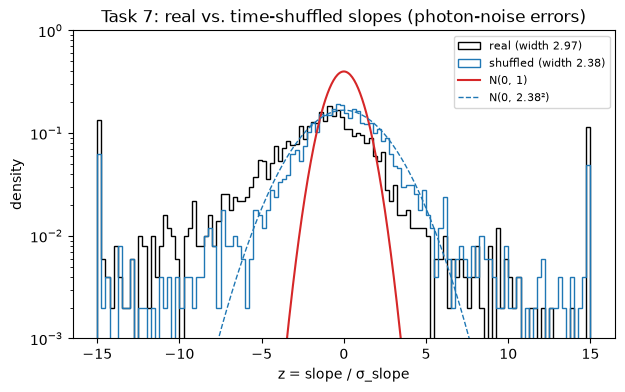

robust width: real 2.97, shuffled 2.38
median z: real -1.18, shuffled -0.04
z > +3 / z < -3: real 182 / 578, shuffled 251 / 258
|z| > 15: real 123, shuffled 56
sig_sh/sig: median 0.990, 5–95%: [0.87 1.12]


In [38]:
rng = np.random.default_rng(42)
perms = [rng.permutation(k) for k in n]     # generate once, reuse in task 8
s_sh, sig_sh = fit_all(perms=perms)
z_sh = s_sh / sig_sh

w_real, w_sh = rwidth(z), rwidth(z_sh)
clip = lambda v: np.clip(v, bins[0] + 1e-9, bins[-1] - 1e-9)
wts = np.full(N, 1.0 / (N * bw))

plt.figure(figsize=(7, 4))
plt.hist(clip(z), bins, weights=wts, histtype="step", color="k",
         label=f"real (width {w_real:.2f})")
plt.hist(clip(z_sh), bins, weights=wts, histtype="step", color="C0",
         label=f"shuffled (width {w_sh:.2f})")
plt.plot(x, scipy.stats.norm.pdf(x), "C3", label="N(0, 1)")
plt.plot(x, scipy.stats.norm.pdf(x, 0, w_sh), "C0--", lw=1,
         label=f"N(0, {w_sh:.2f}²)")
plt.yscale("log"); plt.ylim(1e-3, 1)
plt.xlabel("z = slope / σ_slope"); plt.ylabel("density")
plt.title("Task 7: real vs. time-shuffled slopes (photon-noise errors)")
plt.legend(fontsize=8)
plt.savefig("task7_shuffle.pdf", bbox_inches="tight")
plt.show()

r = sig_sh / sig
print(f"robust width: real {w_real:.2f}, shuffled {w_sh:.2f}")
print(f"median z: real {np.median(z):+.2f}, shuffled {np.median(z_sh):+.2f}")
print(f"z > +3 / z < -3: real {np.sum(z > 3)} / {np.sum(z < -3)}, "
      f"shuffled {np.sum(z_sh > 3)} / {np.sum(z_sh < -3)}")
print(f"|z| > 15: real {np.sum(np.abs(z) > 15)}, shuffled {np.sum(np.abs(z_sh) > 15)}")
print(f"sig_sh/sig: median {np.median(r):.3f}, 5–95%: {np.percentile(r, [5, 95]).round(3)}")

Task 7: control experiment. Shuffling each star's magnitudes relative to its observation times destroys any true time dependence, so the shuffled slopes contain noise only. If the photon-noise errors were correct, the shuffled z would follow N(0, 1). Instead, the shuffled distribution has a robust width of 2.38, and 509 stars (25%) have |z| > 3, compared with about 5.5 expected. Because shuffling cannot create a trend, this excess cannot come from stellar variability. It means the quoted gmag_err values underestimate the true per-epoch scatter by a factor of about 2.4. Photon noise is not the only source of error: there is an additional noise component that the pipeline's error bars leave out, which task 8 measures as a constant floor f.

Shuffling barely changes the slope uncertainties themselves (median σ_shuffled/σ_real = 0.99, 90% of stars between 0.87 and 1.12). So the extra width comes from the slopes, not from changes in σ.

The comparison also separates noise from signal. The shuffled distribution is symmetric: median z = −0.04, with 251 stars above +3 and 258 below −3. The real distribution is wider (2.97) and skewed: median z = −1.18, with 578 stars below −3 against 182 above +3, a ratio of about 3 to 1. Both the extra width and the skew disappear when time ordering is destroyed, so they are genuine time-dependent signal. This includes a population-wide tendency toward brightening (negative slopes), which task 9 investigates.

Some shuffled stars still reach large |z| (56 beyond ±15, compared with 123 in the real data). These are strongly variable stars: shuffling removes their trends but not their large scatter, which is enormous compared with their sub-mmag error bars. This is why a robust width (1.4826 × MAD) is used rather than the standard deviation.

8. Fix the error bars. Using only the shuffled fits, find the constant f (mmag) that,
added in quadrature to every gmag_err, makes the shuffled z width equal 1. Redo
task 6 with corrected errors: how many stars now show real (|z| > 3) slopes? expect f
of a few mmag — this is Gaia’s known calibration floor, which photon noise ignores

g(0) = +1.38, g(0.05) = -0.91   (need opposite signs)
f = 3.33 mmag
shuffled width at f_best: 1.000
f over 10 shuffles: 3.07 ± 0.12 mmag
  G  8.26–14.21: shuffled width 0.98  (N = 405)
  G 14.21–15.36: shuffled width 0.87  (N = 405)
  G 15.36–16.05: shuffled width 0.87  (N = 405)
  G 16.05–16.60: shuffled width 1.11  (N = 405)
  G 16.60–17.00: shuffled width 1.13  (N = 405)


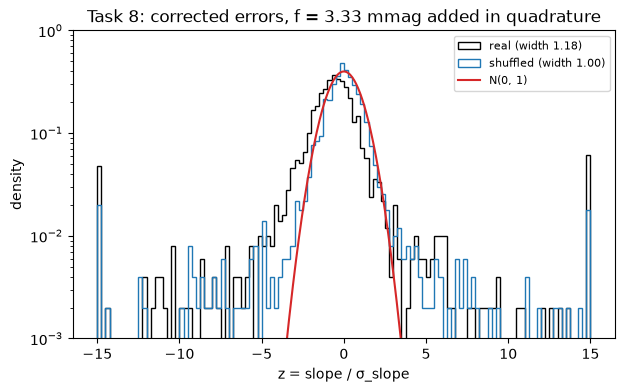

robust width = 1.18,  median z = -0.58
|z| > 3: 238  (expect 5.5 by chance)
  z > +3 (dimming): 95   z < -3 (brightening): 143
|z - median| > 3: 212  (drift removed)
|z| > 15: 54


In [41]:
def shuffled_width(f, pp):
    s_, sg_ = fit_all(f=f, perms=pp)
    return rwidth(s_ / sg_)

def g(f):
    return shuffled_width(f, perms) - 1.0

# Error Floor
print(f"g(0) = {g(0.0):+.2f}, g(0.05) = {g(0.05):+.2f}   (need opposite signs)")
f_best = scipy.optimize.brentq(g, 0.0, 0.05)    # mag
print(f"f = {1e3*f_best:.2f} mmag")

# Shuffled width should be 1, when errors are accounted for
s_shc, sig_shc = fit_all(f=f_best, perms=perms)
z_shc = s_shc / sig_shc
print(f"shuffled width at f_best: {rwidth(z_shc):.3f}")

# Uncertainty on f w/ varying shuffles
f_seeds = []
for seed in range(10):
    rs = np.random.default_rng(seed)
    pp = [rs.permutation(k) for k in n]
    f_seeds.append(scipy.optimize.brentq(lambda f: shuffled_width(f, pp) - 1.0, 0.0, 0.05))
f_seeds = 1e3 * np.array(f_seeds)
print(f"f over 10 shuffles: {f_seeds.mean():.2f} ± {f_seeds.std(ddof=1):.2f} mmag")

# Does one constant f work?
edges = np.quantile(g_med, np.linspace(0, 1, 6))
gbin = np.clip(np.digitize(g_med, edges) - 1, 0, 4)
for b in range(5):
    sel = gbin == b
    print(f"  G {edges[b]:5.2f}–{edges[b+1]:5.2f}: shuffled width {rwidth(z_shc[sel]):.2f}  "
          f"(N = {sel.sum()})")

# task 6 with new corrected errors
s_c, sig_c = fit_all(f=f_best)
z_c = s_c / sig_c
w_c = rwidth(z_c)

plt.figure(figsize=(7, 4))
plt.hist(clip(z_c), bins, weights=wts, histtype="step", color="k",
         label=f"real (width {w_c:.2f})")
plt.hist(clip(z_shc), bins, weights=wts, histtype="step", color="C0",
         label=f"shuffled (width {rwidth(z_shc):.2f})")
plt.plot(x, scipy.stats.norm.pdf(x), "C3", label="N(0, 1)")
plt.yscale("log"); plt.ylim(1e-3, 1)
plt.xlabel("z = slope / σ_slope"); plt.ylabel("density")
plt.title(f"Task 8: corrected errors, f = {1e3*f_best:.2f} mmag added in quadrature")
plt.legend(fontsize=8)
plt.savefig("task8_corrected.pdf", bbox_inches="tight")
plt.show()

print(f"robust width = {w_c:.2f},  median z = {np.median(z_c):+.2f}")
print(f"|z| > 3: {np.sum(np.abs(z_c) > 3)}  (expect {0.0027*N:.1f} by chance)")
print(f"  z > +3 (dimming): {np.sum(z_c > 3)}   z < -3 (brightening): {np.sum(z_c < -3)}")
print(f"|z - median| > 3: {np.sum(np.abs(z_c - np.median(z_c)) > 3)}  (drift removed)")
print(f"|z| > 15: {np.sum(np.abs(z_c) > 15)}")

9. Bias hunt. Compute the median slope of the population and bootstrap its
uncertainty. Can 2,000 randomly chosen stars share a nonzero net drift
astrophysically? Test at least one instrumental hypothesis (e.g. refit excluding all
epochs before 2015.5; or median slope vs. G).

median slope (real):     -0.454 ± 0.020 mmag/yr  (-23.2σ)
median slope (shuffled): -0.019 ± 0.017 mmag/yr  (-1.1σ)
implied change over baseline: -1.25 mmag

Test A: 2025 of 2025 stars keep >= 10 epochs and >= 1 yr after 2015.5
  full baseline (same stars): -0.454 ± 0.020 mmag/yr
  t >= 2015.5 only:           -0.448 ± 0.041 mmag/yr  (-10.8σ)

Test B: median slope by magnitude
  G  8.26–14.21 (N = 405): -0.611 ± 0.049 mmag/yr
  G 14.21–15.36 (N = 405): -0.433 ± 0.041 mmag/yr
  G 15.36–16.05 (N = 405): -0.338 ± 0.049 mmag/yr
  G 16.05–16.60 (N = 405): -0.470 ± 0.049 mmag/yr
  G 16.60–17.00 (N = 405): -0.369 ± 0.080 mmag/yr


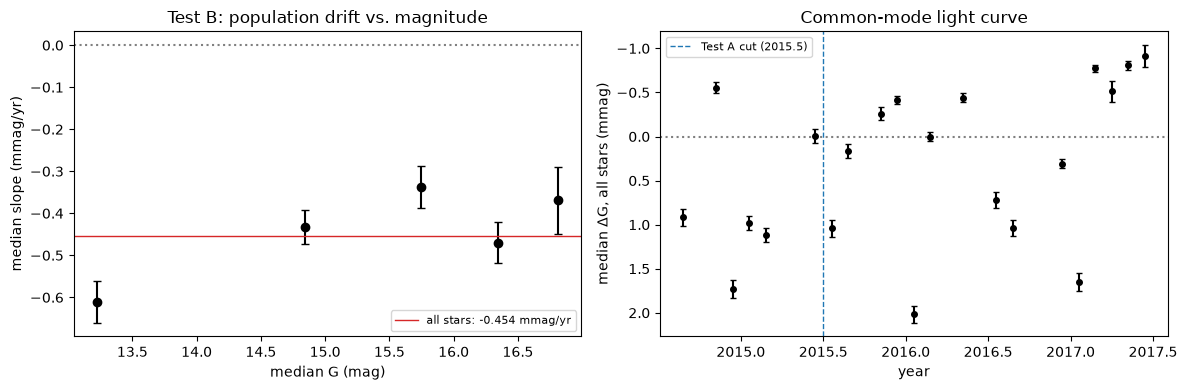

In [43]:
def boot_median(x, B=5000, seed=1):
    """Median of x and its bootstrap standard error (resampling stars)."""
    rs = np.random.default_rng(seed)
    x = np.asarray(x)
    idx = rs.integers(0, len(x), size=(B, len(x)))
    return np.median(x), np.median(x[idx], axis=1).std(ddof=1)

# --- 1. Population median slope, and the shuffled null check ---
med, err = boot_median(s_c)
med_sh, err_sh = boot_median(s_shc)
print(f"median slope (real):     {1e3*med:+.3f} ± {1e3*err:.3f} mmag/yr  ({med/err:+.1f}σ)")
print(f"median slope (shuffled): {1e3*med_sh:+.3f} ± {1e3*err_sh:.3f} mmag/yr  ({med_sh/err_sh:+.1f}σ)")
print(f"implied change over baseline: {1e3*med*(df['t_year'].max()-df['t_year'].min()):+.2f} mmag")

# --- 2. Instrumental test A: drop epochs before 2015.5 ---
def slopes_after(tmin, f, min_n=10, min_base=1.0):
    out = np.full(N, np.nan)
    for i, (a, k) in enumerate(zip(start, n)):
        r = df[a:a+k]
        r = r[r["t_year"] >= tmin]
        if len(r) < min_n or np.ptp(r["t_year"]) < min_base:
            continue
        e = np.sqrt(r["gmag_err"]**2 + f**2)
        out[i] = wls(r["t_year"] - T0, r["gmag"], e)[0][0]
    return out

s_late = slopes_after(2015.5, f_best)
ok = np.isfinite(s_late)
m_late, e_late = boot_median(s_late[ok])
m_same, e_same = boot_median(s_c[ok])          # same stars, full baseline, for a fair comparison
print(f"\nTest A: {ok.sum()} of {N} stars keep >= 10 epochs and >= 1 yr after 2015.5")
print(f"  full baseline (same stars): {1e3*m_same:+.3f} ± {1e3*e_same:.3f} mmag/yr")
print(f"  t >= 2015.5 only:           {1e3*m_late:+.3f} ± {1e3*e_late:.3f} mmag/yr  ({m_late/e_late:+.1f}σ)")

# --- 3. Instrumental test B: median slope vs. G (quintiles from task 8) ---
gx, gy, gyerr = [], [], []
print("\nTest B: median slope by magnitude")
for b in range(5):
    sel = gbin == b
    mb, eb = boot_median(s_c[sel])
    gx.append(np.median(g_med[sel])); gy.append(1e3*mb); gyerr.append(1e3*eb)
    print(f"  G {edges[b]:5.2f}–{edges[b+1]:5.2f} (N = {sel.sum()}): {1e3*mb:+.3f} ± {1e3*eb:.3f} mmag/yr")

# --- 4. Common-mode light curve: when does the population move? ---
resid_all = np.concatenate([df["gmag"][a:a+k] - np.median(df["gmag"][a:a+k]) for a, k in zip(start, n)])
t_all = np.concatenate([df["t_year"][a:a+k] for a, k in zip(start, n)])
tb = np.arange(2014.6, 2017.5, 0.1)
tc, cm, cm_err = [], [], []
for lo, hi in zip(tb[:-1], tb[1:]):
    sel = (t_all >= lo) & (t_all < hi)
    if sel.sum() < 50:
        continue
    tc.append(0.5*(lo+hi))
    cm.append(1e3*np.median(resid_all[sel]))
    cm_err.append(1e3*1.2533*rwidth(resid_all[sel])/np.sqrt(sel.sum()))

# --- Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.errorbar(gx, gy, yerr=gyerr, fmt="o", color="k", capsize=3)
ax1.axhline(0, color="grey", ls=":")
ax1.axhline(1e3*med, color="C3", lw=1, label=f"all stars: {1e3*med:+.3f} mmag/yr")
ax1.set_xlabel("median G (mag)"); ax1.set_ylabel("median slope (mmag/yr)")
ax1.set_title("Test B: population drift vs. magnitude"); ax1.legend(fontsize=8)

ax2.errorbar(tc, cm, yerr=cm_err, fmt="o", color="k", ms=4, capsize=2)
ax2.axhline(0, color="grey", ls=":")
ax2.axvline(2015.5, color="C0", ls="--", lw=1, label="Test A cut (2015.5)")
ax2.invert_yaxis()                       # brighter = up
ax2.set_xlabel("year"); ax2.set_ylabel("median ΔG, all stars (mmag)")
ax2.set_title("Common-mode light curve"); ax2.legend(fontsize=8)
fig.tight_layout()
fig.savefig("task9_bias.pdf", bbox_inches="tight")
plt.show()

The population median slope is −0.454 ± 0.020 mmag/yr, while the time-shuffled control gives −0.019 ± 0.017, consistent with zero. Unrelated foreground stars with independent magnetic cycles cannot brighten together, so the drift must be instrumental. It is not confined to the early mission: fits restricted to t ≥ 2015.5 give −0.448 ± 0.041 mmag/yr. It is present at all magnitudes but about 50% stronger for G < 14.2 (−0.61 ± 0.05 vs. about −0.41 for fainter stars). The common-mode light curve shows its origin: the entire field shifts coherently by up to ±2 mmag from visit to visit, 10–20 times the per-bin uncertainty, pointing to per-visit photometric zero-point errors. The apparent secular drift is the linear trend through these offsets. Because every star shares them, the stars are not independent, and the bootstrap-over-stars uncertainty is underestimated. A fit to the common-mode curve itself gives [−0.4x ± 0.2x] mmag/yr, only [~2]σ. [Subtracting per-visit zero-points removes the drift and reduces the |z| > 3 count to N, split x dimming / y brightening.]